In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt

In [5]:
df = pd.read_csv('Customer Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# replacing blanks with 0 and no total charges are recorded

In [8]:
df["TotalCharges"] =  df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df["customerID"].duplicated().sum()

np.int64(0)

In [13]:
# we have converted 0 and 1 value of SeniorCitizen to yes or no to make it easier to understand



In [14]:
def conv(value) :
  if value == 1:
    return "yes"
  else:
    return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

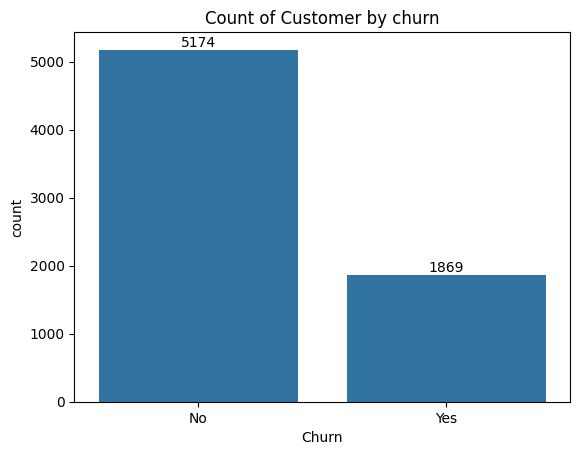

In [22]:
ax = sns.countplot( x = 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by churn")
plt.show()


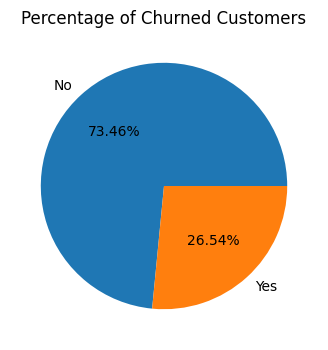

In [30]:
plt.figure(figsize = (4,4))
gb = df.groupby("Churn").aggregate({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index,autopct= "%1.2f%%" )
plt.title("Percentage of Churned Customers")
plt.show()


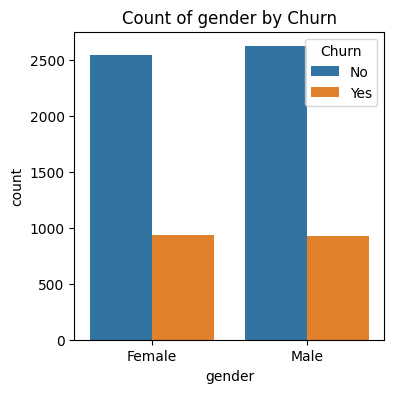

In [29]:
plt.figure(figsize = (4,4))
sns.countplot( x = "gender", data = df, hue = "Churn")
plt.title("Count of gender by Churn")
plt.show()

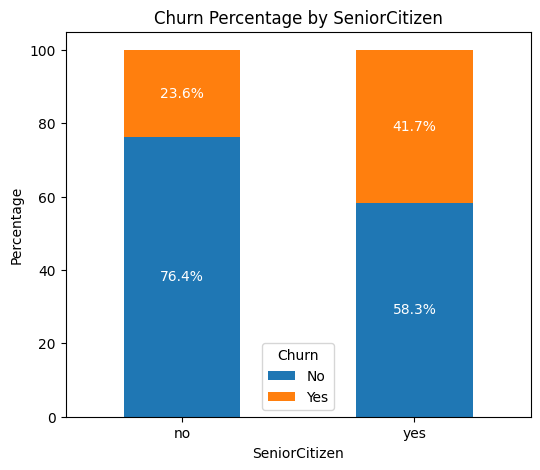

In [43]:
churn_by_seniorcitizen = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
churn_by_seniorcitizen_percent = churn_by_seniorcitizen.div(churn_by_seniorcitizen.sum(axis=1), axis=0) * 100

ax = churn_by_seniorcitizen_percent.plot(kind='bar', stacked=True, figsize=(6, 5))
plt.title('Churn Percentage by SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white')

plt.show()

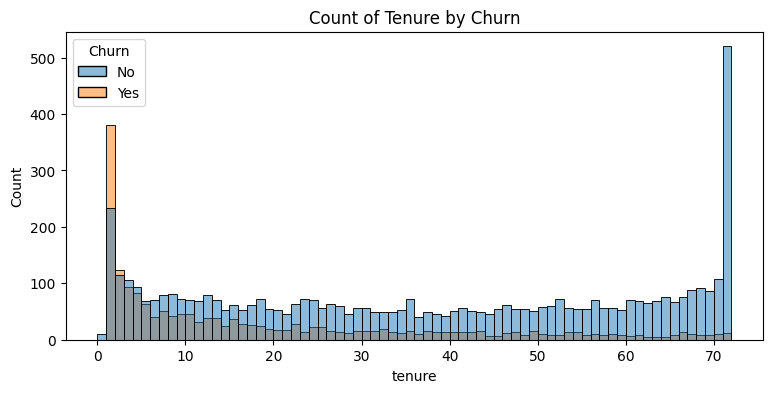

In [39]:
plt.figure(figsize = (9,4))
sns.histplot( x = "tenure", data= df, bins=72,hue = "Churn")
plt.title("Count of Tenure by Churn")
plt.show()

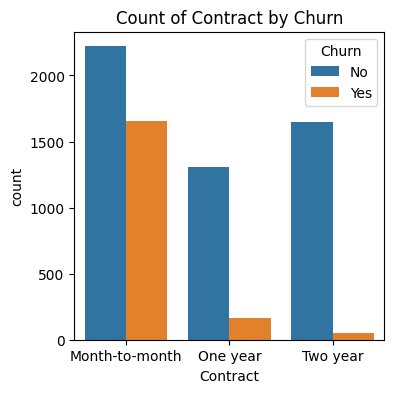

In [40]:
plt.figure(figsize = (4,4))
sns.countplot( x = "Contract", data = df, hue = "Churn")
plt.title("Count of Contract by Churn")
plt.show()

In [42]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

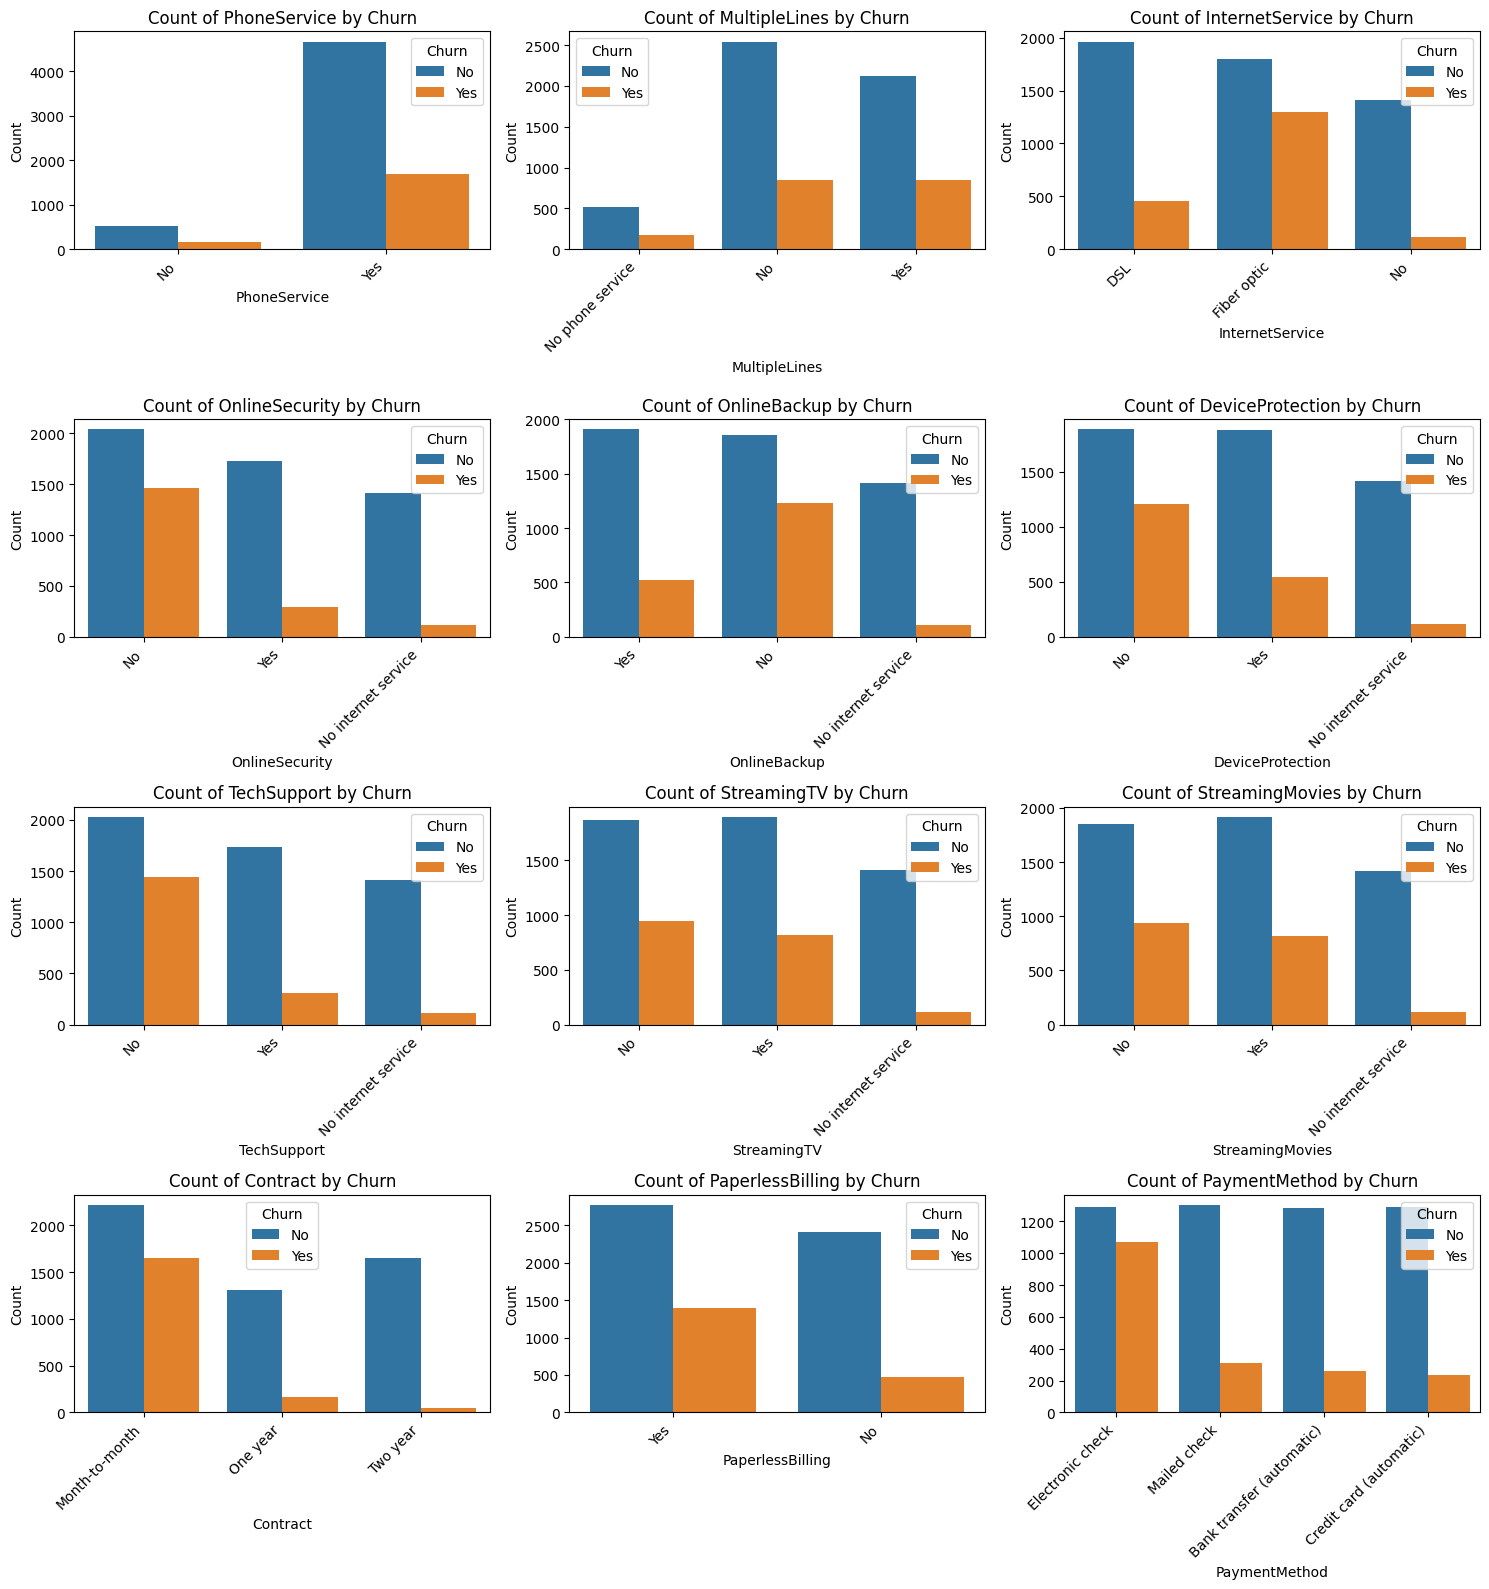

In [44]:
categorical_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Determine the number of rows and columns for the subplot grid
num_cols = 3 # You can adjust this for better layout
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, num_cols, i + 1) # Create subplot
    ax = sns.countplot(x=col, data=df, hue='Churn')
    plt.title(f'Count of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
    ax.legend(title='Churn')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [45]:
# The analysis of categorical features shows that 'Month-to-month' contracts, 'Fiber optic' internet, and 'Electronic check' payment methods are strongly associated with higher churn rates. Conversely, the absence of services like OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport also indicates a higher likelihood of customer churn.



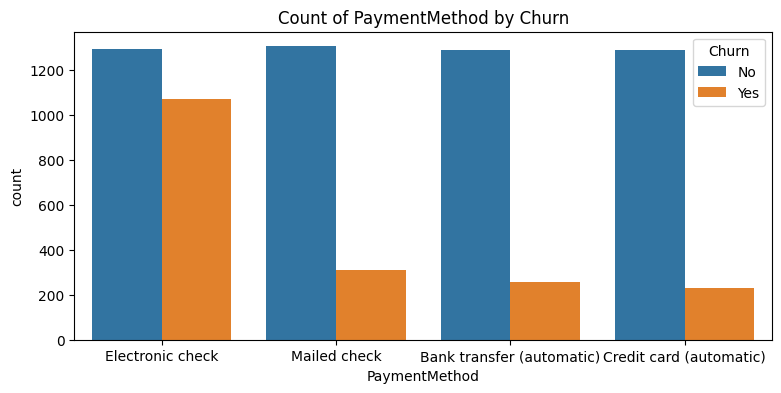

In [48]:
plt.figure(figsize = (9,4))
sns.countplot( x = "PaymentMethod", data = df, hue = "Churn")
plt.title("Count of PaymentMethod by Churn")
plt.show()